# Import Libraries

In [1]:
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.transform import resize

from sklearn.utils import shuffle 
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adamax
from sklearn.metrics import classification_report, confusion_matrix

2025-08-26 01:38:06.463648: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-26 01:38:06.463805: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-26 01:38:06.772608: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# 1. Configuration and Data Paths

In [ ]:
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

train_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Training"
test_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Testing"


X_train = [] #Training Dataset
Y_train = [] #Training Labels

image_size=224

for label in labels:
    path = os.path.join(train_dir, label)
    class_num = labels.index(label)
    for img in os.listdir(path):
        img_array = plt.imread(os.path.join(path, img))
        img_resized = resize(img_array, (image_size, image_size, 3))
        X_train.append(img_resized)
        Y_train.append(class_num)

for label in labels:
    path = os.path.join(test_dir, label)
    class_num = labels.index(label)
    for img in os.listdir(path):
        img_array = plt.imread(os.path.join(path, img))
        img_resized = resize(img_array, (image_size, image_size, 3))
        X_train.append(img_resized)
        Y_train.append(class_num)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

In [3]:
#Number of sample = 7023
X_train.shape

(7023, 224, 224, 3)

In [4]:
X_train, Y_train = shuffle(X_train, Y_train, random_state=42)

In [5]:
#After shuffling sample size remains same
X_train.shape

(7023, 224, 224, 3)

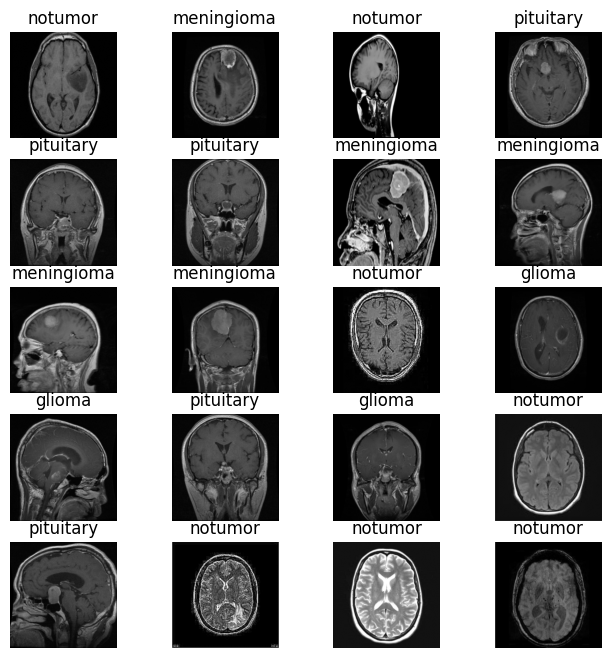

In [6]:
#plotting the images
plt.figure(figsize=(8,8))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(X_train[i])
    plt.title(labels[Y_train[i]])
    plt.axis("off")
plt.show()

In [7]:
# Split the data into training and testing and validation
X_train, X_test, Y_train, Y_test = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)

In [8]:
# Data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

# convert string to categorical
y_train_new = to_categorical(Y_train, num_classes=4)
y_valid_new = to_categorical(Y_valid, num_classes=4)
y_test_new = to_categorical(Y_test, num_classes=4)

In [9]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define image size
image_size = 224  # Adjust according to your dataset

# Build a custom CNN model
model = Sequential([
    # First convolutional block
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(image_size, image_size, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Second convolutional block
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Third convolutional block
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Fourth convolutional block
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Global pooling and fully connected layers
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # Assuming 4 classes
])

# Compile the model
model.compile(Adamax(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('custom_model.h5', monitor='val_loss', save_best_only=True)

# Model summary
model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 112, 112, 64)      256       
 chNormalization)                                                
                                                        

In [10]:
# Fit the model
history = model.fit(datagen.flow(X_train, y_train_new, batch_size=32),
                    epochs=12,  # Increase the number of epochs as needed
                    validation_data=(X_valid, y_valid_new),
                    callbacks=[early_stopping, checkpoint])

Epoch 1/12


I0000 00:00:1756172509.286753     630 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


158/158 [==============================] - 56s 289ms/step - loss: 1.2701 - accuracy: 0.4761 - val_loss: 1.8692 - val_accuracy: 0.2295
Epoch 2/12


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


158/158 [==============================] - 45s 284ms/step - loss: 1.0900 - accuracy: 0.5500 - val_loss: 2.1183 - val_accuracy: 0.3452
Epoch 3/12
158/158 [==============================] - 45s 286ms/step - loss: 1.0353 - accuracy: 0.5803 - val_loss: 1.1729 - val_accuracy: 0.5125
Epoch 4/12
158/158 [==============================] - 46s 290ms/step - loss: 0.9677 - accuracy: 0.6078 - val_loss: 0.8705 - val_accuracy: 0.6423
Epoch 5/12
158/158 [==============================] - 46s 288ms/step - loss: 0.9173 - accuracy: 0.6286 - val_loss: 0.8047 - val_accuracy: 0.6815
Epoch 6/12
158/158 [==============================] - 45s 287ms/step - loss: 0.9075 - accuracy: 0.6410 - val_loss: 0.8245 - val_accuracy: 0.6797
Epoch 7/12
158/158 [==============================] - 45s 284ms/step - loss: 0.8701 - accuracy: 0.6525 - val_loss: 0.8075 - val_accuracy: 0.6708
Epoch 8/12
158/158 [==============================] - 45s 282ms/step - loss: 0.8349 - accuracy: 0.6630 - val_loss: 0.8055 - val_accuracy: 0.6

In [11]:
# Load the best model
model = load_model('custom_model.h5')

In [12]:
from IPython.display import FileLink

# This will generate a direct link to the saved file
# You can click this link to start the download
FileLink('custom_model.h5')

/kaggle/working/custom_model.h5

44/44 [==============================] - 2s 45ms/step - loss: 0.7287 - accuracy: 0.7253


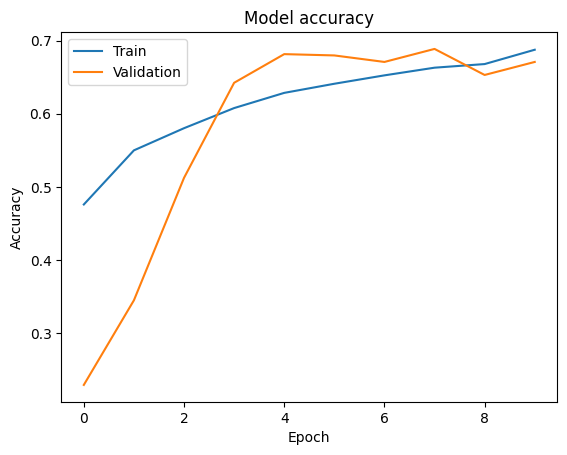

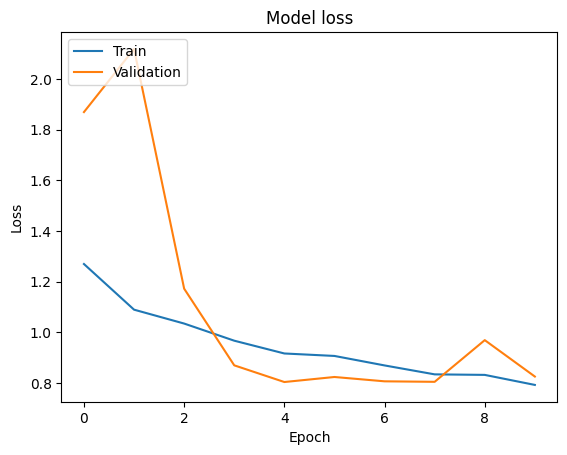

In [13]:
#Evaluate the model
model.evaluate(X_test, y_test_new)

# Plot the accuracy and loss
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

44/44 [==============================] - 1s 22ms/step


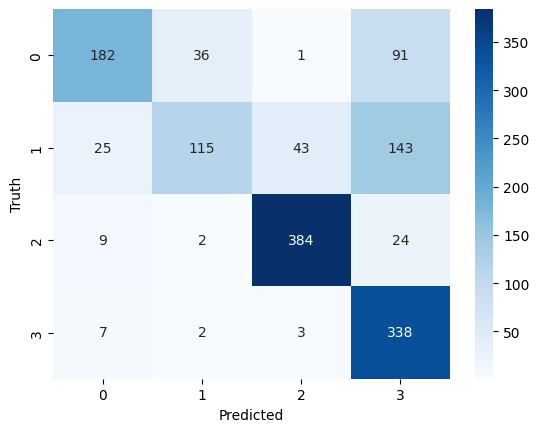

In [14]:
# Predict the model
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [15]:
# Classification report
print(classification_report(Y_test, y_pred, target_names=labels))

              precision    recall  f1-score   support

      glioma       0.82      0.59      0.68       310
  meningioma       0.74      0.35      0.48       326
     notumor       0.89      0.92      0.90       419
   pituitary       0.57      0.97      0.71       350

    accuracy                           0.73      1405
   macro avg       0.75      0.71      0.69      1405
weighted avg       0.76      0.73      0.71      1405



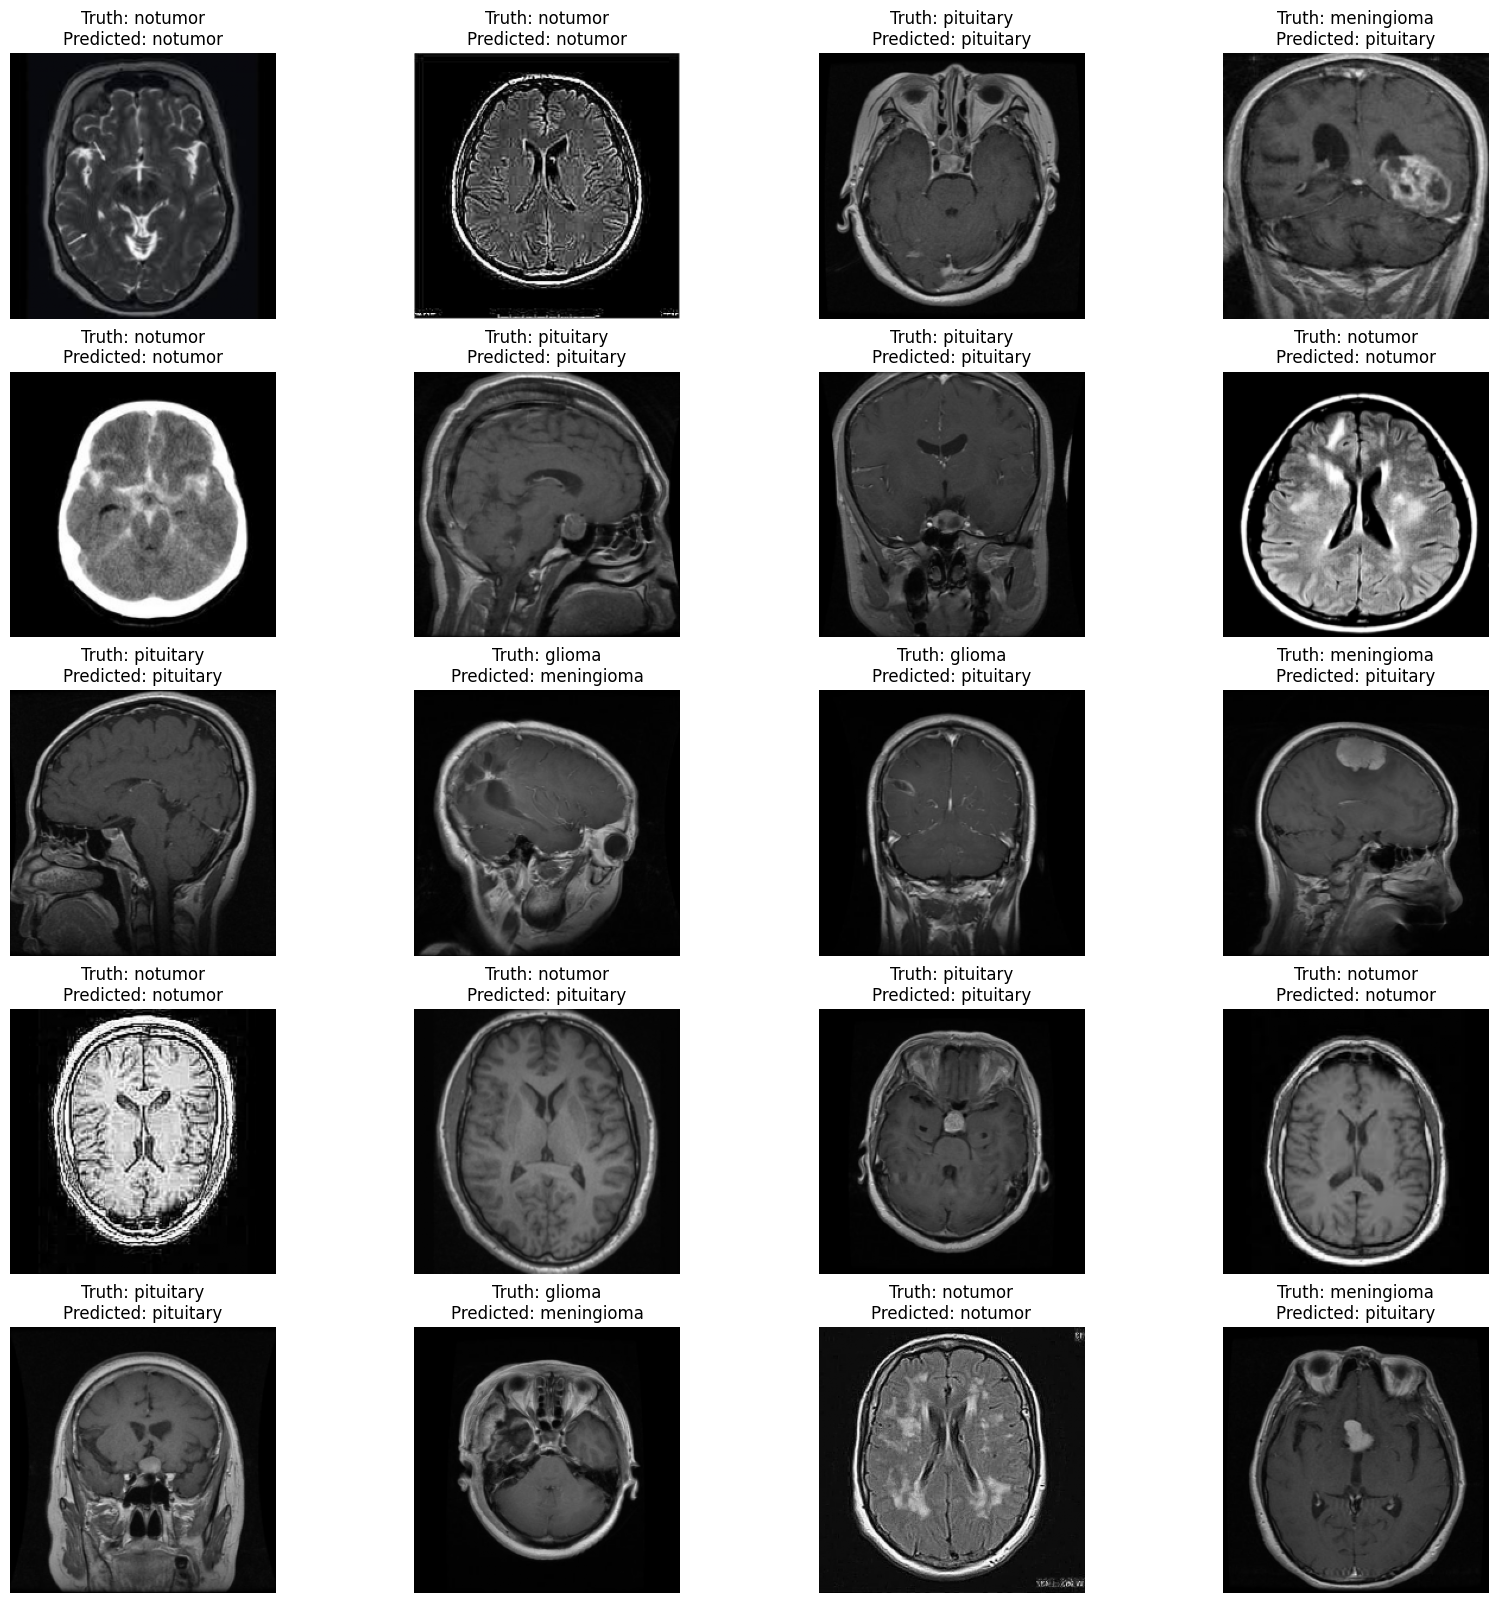

In [16]:
# Visualizing Model Predictions
plt.figure(figsize=(20,20))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Truth: {labels[Y_test[i]]}\nPredicted: {labels[y_pred[i]]}")
    plt.axis('off')
plt.show()

In [17]:
#testing accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test, y_pred))

0.7252669039145907
